In [1]:
import torch
from transformers import AutoConfig, AutoImageProcessor, AutoModelForVision2Seq, AutoProcessor
from IPython.display import display
import torch.nn.functional as F

import time
import numpy as np
import cv2
import textwrap
from PIL import Image, ImageDraw, ImageFont
import enum

import sys
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Sequence

from PIL import Image
from tqdm import tqdm

# ------------------------------------------------------------
# Make OpenVLA helper imports work if script is placed nearby
# ------------------------------------------------------------
_THIS_DIR = Path().absolute()
_PROJECT_ROOT = _THIS_DIR
for _ in range(6):
    if (_PROJECT_ROOT / "experiments").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent
    print(f"Searching for project root, checking {_PROJECT_ROOT}...")
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))
    print(f"Added {_PROJECT_ROOT} to sys.path for imports.")
# sys.path.insert(0, "/home/seram/ut/project/LGVLA/LIBERO")

from libero.libero import benchmark

sys.path.insert(0, "/home/seram/ut/project/LGVLA/LIBERO/openvla")

try:
    from experiments.robot.libero.libero_utils import (
        get_libero_dummy_action,
        get_libero_env,
        get_libero_image,
        save_rollout_video,
    )
except Exception as exc:
    raise RuntimeError(
        "Could not import experiments.robot.libero.libero_utils. "
        "Place this file inside an OpenVLA-style workspace or adapt the imports."
    ) from exc


2026-04-03 14:21:06.360743: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-03 14:21:06.360770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-03 14:21:06.361848: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-03 14:21:06.366757: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-03 14:21:06.902655: W tensorflow/compiler/tf2

In [2]:
#Define some utils.

def split_reasoning(text, tags):
    new_parts = {None: text}

    for tag in tags:
        parts = new_parts
        new_parts = dict()

        for k, v in parts.items():
            if tag in v:
                s = v.split(tag)
                new_parts[k] = s[0]
                new_parts[tag] = s[1]
                # print(tag, s)
            else:
                new_parts[k] = v

    return new_parts

class CotTag(enum.Enum):
    TASK = "TASK:"
    PLAN = "PLAN:"
    VISIBLE_OBJECTS = "VISIBLE OBJECTS:"
    SUBTASK_REASONING = "SUBTASK REASONING:"
    SUBTASK = "SUBTASK:"
    MOVE_REASONING = "MOVE REASONING:"
    MOVE = "MOVE:"
    GRIPPER_POSITION = "GRIPPER POSITION:"
    ACTION = "ACTION:"


def get_cot_tags_list():
    return [
        CotTag.TASK.value,
        CotTag.PLAN.value,
        CotTag.VISIBLE_OBJECTS.value,
        CotTag.SUBTASK_REASONING.value,
        CotTag.SUBTASK.value,
        CotTag.MOVE_REASONING.value,
        CotTag.MOVE.value,
        CotTag.GRIPPER_POSITION.value,
        CotTag.ACTION.value,
    ]

def name_to_random_color(name):
    return [(hash(name) // (256**i)) % 256 for i in range(3)]




def draw_gripper(img, pos_list, img_size=(640, 480)):
    for i, pos in enumerate(reversed(pos_list)):
        pos = resize_pos(pos, img_size)
        scale = 255 - int(255 * i / len(pos_list))
        cv2.circle(img, pos, 6, (0, 0, 0), -1)
        cv2.circle(img, pos, 5, (scale, scale, 255), -1)

def get_metadata(reasoning):
    metadata = {"gripper": [[0, 0]], "bboxes": dict()}

    if f" {CotTag.GRIPPER_POSITION.value}" in reasoning:
        gripper_pos = reasoning[f" {CotTag.GRIPPER_POSITION.value}"]
        gripper_pos = gripper_pos.split("[")[-1]
        gripper_pos = gripper_pos.split("]")[0]
        gripper_pos = [int(x) for x in gripper_pos.split(",")]
        gripper_pos = [(gripper_pos[2 * i], gripper_pos[2 * i + 1]) for i in range(len(gripper_pos) // 2)]
        metadata["gripper"] = gripper_pos

    if f" {CotTag.VISIBLE_OBJECTS.value}" in reasoning:
        for sample in reasoning[f" {CotTag.VISIBLE_OBJECTS.value}"].split("]"):
            obj = sample.split("[")[0]
            if obj == "":
                continue
            # coords = [int(n) for n in sample.split("[")[-1].split(",")]
            coords = [
                int(n.strip())
                for n in sample.split("[")[-1].split("]")[0].split(",")
                if n.strip() != ""
            ]
            metadata["bboxes"][obj] = coords

    return metadata

def resize_pos(pos, img_size):
    return [(x * size) // 256 for x, size in zip(pos, img_size)]

def draw_bboxes(img, bboxes, img_size=(640, 480)):
    for name, bbox in bboxes.items():
        if not bbox or len(bbox) < 4:  # skip empty/malformed bboxes
            continue
        show_name = name
        # show_name = f'{name}; {str(bbox)}'

        cv2.rectangle(
            img,
            resize_pos((bbox[0], bbox[1]), img_size),
            resize_pos((bbox[2], bbox[3]), img_size),
            name_to_random_color(name),
            1,
        )
        cv2.putText(
            img,
            show_name,
            resize_pos((bbox[0], bbox[1] + 6), img_size),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
        


In [3]:
from transformers import AutoModelForVision2Seq
from PIL import Image
import torch

device = "cuda:1" if torch.cuda.is_available() else "cpu"
# path = "Embodied-CoT/ecot-openvla-7b-bridge"
# path = "leepanic/ecot-libero-spatial-r1024"
path = "leepanic/ecot-libero-spatial-r32"

processor = AutoProcessor.from_pretrained(path, trust_remote_code=True)
vla = AutoModelForVision2Seq.from_pretrained(
    path,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
).to(device)

tokenizer = processor.tokenizer


/home/seram/anaconda3/envs/ood/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


/home/seram/anaconda3/envs/ood/lib/python3.10/site-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/seram/anaconda3/envs/ood/lib/python3.10/site-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
/home/seram/anaconda3/envs/ood/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/home/seram/anaconda3/envs/ood/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
class FrozenPromptController:
    def __init__(vla, max_freezing_time=5, base_prefix=" TASK:"):
        vla.max_freezing_time = max_freezing_time
        vla.base_prefix = base_prefix
        vla.frozen_prefix = base_prefix
        vla.time_frozen = 0

    def get_prefix_for_step(vla):
        if vla.time_frozen <= 0:
            vla.frozen_prefix = vla.base_prefix
            vla.time_frozen = vla.max_freezing_time

        vla.time_frozen -= 1
        return vla.frozen_prefix

    def update_from_decoded(vla, decoded_text: str):
        vla.frozen_prefix = extract_cached_reasoning_prefix(decoded_text)
        
def build_chat_prompt(instruction: str) -> str:
    return (
        "A chat between a curious user and an artificial intelligence assistant. "
        "The assistant gives helpful, detailed, and polite answers to the user's questions. "
        f"USER: What action should the robot take to {instruction.lower()}? ASSISTANT:"
    )

def build_prefixed_input_ids(instruction: str, prefix_text: str = "", device: str = "cuda"):
    base_prompt = build_chat_prompt(instruction)
    base_ids = tokenizer(
        base_prompt,
        truncation=True,
        return_tensors="pt",
    ).input_ids.to(device)

    if prefix_text == "":
        return base_ids

    prefix_ids = tokenizer(
        prefix_text,
        return_tensors="pt",
    ).input_ids.to(device)[:, 1:]

    return torch.cat((base_ids, prefix_ids), dim=1)

def preprocess_image(image: Image.Image, device: str):
    return processor.image_processor(image, return_tensors="pt")["pixel_values"].to(
        device,
        dtype=torch.bfloat16 if str(device).startswith("cuda") else torch.float32,
    )

def run_generate(image, instruction, prefix_text="", max_new_tokens=1024, unnorm_key="bridge_reasoning"):
    input_ids = build_prefixed_input_ids(instruction, prefix_text, device)
    pixel_values = preprocess_image(image, device)

    with torch.inference_mode():
        generated_ids = vla.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

        # Extract predicted action tokens and translate into (normalized) continuous actions
        predicted_action_token_ids = generated_ids[0, -vla.get_action_dim(unnorm_key) :].cpu().numpy()
        discretized_actions = vla.vocab_size - predicted_action_token_ids
        discretized_actions = np.clip(
            discretized_actions - 1, a_min=0, a_max=vla.bin_centers.shape[0] - 1
        )
        normalized_actions = vla.bin_centers[discretized_actions]

        # Unnormalize actions
        action_norm_stats = vla.get_action_stats(unnorm_key)
        mask = action_norm_stats.get("mask", np.ones_like(action_norm_stats["q01"], dtype=bool))
        action_high, action_low = np.array(action_norm_stats["q99"]), np.array(action_norm_stats["q01"])
        actions = np.where(
            mask,
            0.5 * (normalized_actions + 1) * (action_high - action_low) + action_low,
            normalized_actions,
        )
        
    # decoded = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    decoded = processor.batch_decode(generated_ids)[0]
    return actions, decoded

def extract_cached_reasoning_prefix(decoded_text: str) -> str:
    # Adapt this parser to your actual output format
    text = decoded_text

    if "\nOut: " in text:
        text = text.split("\nOut: ")[-1]
    if "ASSISTANT:" in text:
        text = text.split("ASSISTANT:")[-1].strip()

    if " MOVE REASONING: " in text:
        return text.split(" MOVE REASONING: ")[0] + " MOVE REASONING: "

    if " GRIPPER POSITION: " in text:
        return text.split(" GRIPPER POSITION: ")[0] + " GRIPPER POSITION: "

    return "TASK:"

def run_generate_with_entropy(
    image,
    instruction,
    prefix_text="",
    max_new_tokens=1024,
    unnorm_key="bridge_reasoning",
):
    input_ids = build_prefixed_input_ids(instruction, prefix_text, device)
    pixel_values = preprocess_image(image, device)

    with torch.inference_mode():
        out = vla.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
        )

        generated_ids = out.sequences
        scores = out.scores  # tuple of length = number of newly generated tokens

        action_dim = vla.get_action_dim(unnorm_key)

        # Final generated action token IDs
        predicted_action_token_ids = generated_ids[0, -action_dim:].cpu().numpy()

        # Convert token IDs to normalized actions
        discretized_actions = vla.vocab_size - predicted_action_token_ids
        discretized_actions = np.clip(
            discretized_actions - 1,
            a_min=0,
            a_max=vla.bin_centers.shape[0] - 1,
        )
        normalized_actions = vla.bin_centers[discretized_actions]

        # Unnormalize actions
        action_norm_stats = vla.get_action_stats(unnorm_key)
        mask = action_norm_stats.get("mask", np.ones_like(action_norm_stats["q01"], dtype=bool))
        action_high = np.array(action_norm_stats["q99"])
        action_low = np.array(action_norm_stats["q01"])
        actions = np.where(
            mask,
            0.5 * (normalized_actions + 1) * (action_high - action_low) + action_low,
            normalized_actions,
        )

        # Entropy for the last `action_dim` generated tokens
        # scores[t]: logits for generated token step t
        action_scores = scores[-action_dim:]

        entropies = []
        selected_token_logprobs = []

        for step_logits, token_id in zip(action_scores, predicted_action_token_ids):
            # step_logits shape: [batch=1, vocab]
            log_probs = F.log_softmax(step_logits[0], dim=-1)
            probs = log_probs.exp()

            entropy = -(probs * log_probs).sum().item()
            entropies.append(entropy)

            selected_logprob = log_probs[token_id].item()
            selected_token_logprobs.append(selected_logprob)

    decoded = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

    return {
        "actions": actions,
        "decoded": decoded,
        "generated_ids": generated_ids,
        "predicted_action_token_ids": predicted_action_token_ids,
        "action_token_entropies": np.array(entropies),
        "action_token_logprobs": np.array(selected_token_logprobs),
        "mean_action_entropy": float(np.mean(entropies)),
        "scores": scores,
        "action_scores": action_scores,
    }
    
import torch
import numpy as np

ACTION_TOKEN_BEGIN_IDX = 31743
N_ACTION_BINS = 256
ACTION_TOKEN_START = ACTION_TOKEN_BEGIN_IDX + 1
ACTION_TOKEN_END   = ACTION_TOKEN_START + N_ACTION_BINS

def compute_step_uncertainty_from_action_scores(action_scores):
    """
    action_scores: list/tuple of length 7
        each element shape [1, vocab_size] or [vocab_size]

    returns:
        dict with:
            entropy_per_slot: [7]
            top3_mass_per_slot: [7]
            entropy_mean: scalar
            top3_mass_mean: scalar
            logits_7xV: [7, vocab_size]
    """
    step_logits = torch.stack(
        [x.squeeze(0).float().cpu() for x in action_scores],
        dim=0
    )  # [7, vocab_size]

    action_logits = step_logits[:, ACTION_TOKEN_START:ACTION_TOKEN_END]  # [7, 256]
    probs = torch.softmax(action_logits, dim=-1)

    entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=-1)         # [7]
    top3_mass = torch.topk(probs, k=3, dim=-1).values.sum(dim=-1)     # [7]

    return {
        "entropy_per_slot": entropy.numpy(),
        "top3_mass_per_slot": top3_mass.numpy(),
        "entropy_mean": float(entropy.mean().item()),
        "top3_mass_mean": float(top3_mass.mean().item()),
        "logits_7xV": step_logits,
    }

In [5]:
def visualize_reasoning(image: Image.Image, generated_text: str, img_size: tuple = (640, 480)) -> Image.Image:
    tags = [f" {tag}" for tag in get_cot_tags_list()]
    reasoning = split_reasoning(generated_text, tags)
    text = [tag + reasoning[tag] for tag in [' TASK:',' PLAN:',' SUBTASK REASONING:',' SUBTASK:',
                                            ' MOVE REASONING:',' MOVE:', ' VISIBLE OBJECTS:', ' GRIPPER POSITION:'] if tag in reasoning]
    metadata = get_metadata(reasoning)
    bboxes = {}
    for k, v in metadata["bboxes"].items():
        if k[0] == ",":
            k = k[1:]
        bboxes[k.lstrip().rstrip()] = v

    caption = ""
    for t in text:
        wrapper = textwrap.TextWrapper(width=80, replace_whitespace=False) 
        word_list = wrapper.wrap(text=t) 
        caption_new = ''
        for ii in word_list[:-1]:
            caption_new = caption_new + ii + '\n      '
        caption_new += word_list[-1]

        caption += caption_new.lstrip() + "\n\n"

    base = Image.fromarray(np.ones((480, 640, 3), dtype=np.uint8) * 255)
    draw = ImageDraw.Draw(base)
    font = ImageFont.load_default(size=14) # big text
    color = (0,0,0) # RGB
    draw.text((30, 30), caption, color, font=font)

    image = image.resize(img_size)
    img_arr = np.array(image)
    draw_gripper(img_arr, metadata["gripper"], img_size=img_size)
    draw_bboxes(img_arr, bboxes, img_size=img_size)

    text_arr = np.array(base)

    reasoning_img = Image.fromarray(np.concatenate([img_arr, text_arr], axis=1))
    
    return reasoning_img

In [6]:
from pathlib import Path
import torch
import numpy as np

def save_rollout_pt(
    save_dir,
    task_name,
    task_id,
    trial_id,
    success,
    step_ids,
    rollout_logits,
):
    """
    rollout_logits: list of [7, vocab_size] tensors, one per simulation step
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if len(rollout_logits) == 0:
        logits = torch.empty(0)
    else:
        logits = torch.stack(rollout_logits, dim=0).float()   # [T, 7, vocab]

    payload = {
        "task_name": str(task_name),
        "task_id": int(task_id),
        "trial_id": int(trial_id),
        "success": int(success),
        "step_ids": np.asarray(step_ids, dtype=np.int32),
        "logits": logits,
    }

    pt_path = save_dir / f"task{task_id:02d}_trial{trial_id:02d}.pt"
    torch.save(payload, pt_path)
    return pt_path

In [7]:
def run_one_rollout_ecot(
    env,
    task_description,
    task_id,
    trial_id,
    max_steps,
    save_dir,
    image_from_obs_fn,
    use_frozen_prompt_controller=True,
    unnorm_key="bridge_reasoning",
):
    """
    env: LIBERO env already resettable
    image_from_obs_fn(obs) -> PIL image
    """

    obs = env.reset()
    success = 0

    rollout_logits = []
    step_ids = []

    entropy_series = []
    top3_mass_series = []
    
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    img_dir = save_dir / "frames"
    img_dir.mkdir(exist_ok=True)

    if use_frozen_prompt_controller:
        controller = FrozenPromptController(max_freezing_time=5, base_prefix=" TASK:")
    prefix_text = " TASK:"
    for t in tqdm(range(max_steps), desc="Rollout Steps"):
        image = image_from_obs_fn(obs)
        frame_path = img_dir / f"step_{t:03d}.png"
        image.save(frame_path)
        
        if use_frozen_prompt_controller:
            prefix_text = controller.get_prefix_for_step()

        result = run_generate_with_entropy(
            image=image,
            instruction=task_description,
            prefix_text=prefix_text,
            unnorm_key=unnorm_key,   # important for your checkpoint
        )

        # optional reasoning-prefix update
        if use_frozen_prompt_controller:
            controller.update_from_decoded(result["decoded"])

        # uncertainty from this step
        uq = compute_step_uncertainty_from_action_scores(result["action_scores"])
        rollout_logits.append(uq["logits_7xV"])   # [7, vocab]
        step_ids.append(t)

        entropy_series.append(uq["entropy_mean"])
        top3_mass_series.append(uq["top3_mass_mean"])

        # continuous action from ECoT
        action = result["actions"]

        obs, reward, done, info = env.step(action.tolist())

        if done:
            success = 1
            break

    pt_path = save_rollout_pt(
        save_dir=save_dir,
        task_name=task_description,
        task_id=task_id,
        trial_id=trial_id,
        success=success,
        step_ids=step_ids,
        rollout_logits=rollout_logits,
    )

    return {
        "success": success,
        "traj_len": len(step_ids),
        "entropy_series": np.asarray(entropy_series),
        "top3_mass_series": np.asarray(top3_mass_series),
        "pt_path": str(pt_path),
    }
    
def to_image(obs: dict) -> Image.Image:
    rgb = get_libero_image(obs, 224) # 224 for openVLA
    if isinstance(rgb, Image.Image):
        return rgb
    return Image.fromarray(np.asarray(rgb).astype(np.uint8))


In [8]:
import json
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

def debug_one_task(
    task_suite,
    task_id=0,
    trial_id=0,
    max_steps=80,
    out_dir="./debug_ecot_one_task",
    use_frozen_prompt_controller=False,
    unnorm_key="bridge_reasoning",
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    img_dir = out_dir / "frames"
    img_dir.mkdir(exist_ok=True)

    task = task_suite.get_task(task_id)
    initial_states = task_suite.get_task_init_states(task_id)
    env, task_description = get_libero_env(task, "openvla", resolution=256)

    print("TASK:", task_description)

    env.reset()
    obs = env.set_init_state(initial_states[trial_id % len(initial_states)])

    if use_frozen_prompt_controller:
        controller = FrozenPromptController(max_freezing_time=5, base_prefix=" TASK:")
    else:
        prefix_text = " TASK:"
    records = []

    for t in range(max_steps):
        image = to_image(obs)   # your get_libero_image(obs, 224) path
        if use_frozen_prompt_controller:
            prefix_text = controller.get_prefix_for_step()

        result = run_generate_with_entropy(
            image=image,
            instruction=task_description,
            prefix_text=prefix_text,
            unnorm_key=unnorm_key,
        )

        if use_frozen_prompt_controller:
            controller.update_from_decoded(result["decoded"])
        uq = compute_step_uncertainty_from_action_scores(result["action_scores"])

        action = np.asarray(result["actions"], dtype=np.float32)
        obs, reward, done, info = env.step(action.tolist())

        frame_path = img_dir / f"step_{t:03d}.png"
        image.save(frame_path)

        rec = {
            "step": t,
            "prompt_prefix": prefix_text,
            "decoded": result["decoded"],
            "action": action.tolist(),
            "entropy_mean": float(uq["entropy_mean"]),
            "top3_mass_mean": float(uq["top3_mass_mean"]),
            "done": bool(done),
            "reward": float(reward),
            "info": str(info),
        }
        records.append(rec)

        print(f"\n--- step {t} ---")
        print("entropy:", rec["entropy_mean"])
        print("top3_mass:", rec["top3_mass_mean"])
        print("action:", np.round(action, 4))
        print("decoded preview:", result["decoded"][:400])

        if done:
            print(f"\nSUCCESS at step {t}")
            break

    with open(out_dir / "trace.json", "w") as f:
        json.dump(records, f, indent=2)

    env.close()
    return records

In [9]:
# def show_debug_step(debug_dir, step_idx):
#     debug_dir = Path(debug_dir)
#     with open(debug_dir / "trace.json", "r") as f:
#         trace = json.load(f)

#     rec = trace[step_idx]
#     img = Image.open(debug_dir / "frames" / f"step_{step_idx:03d}.png")

#     plt.figure(figsize=(7, 7))
#     plt.imshow(img)
#     plt.axis("off")
#     plt.title(
#         f"step={rec['step']} | entropy={rec['entropy_mean']:.3f} | "
#         f"top3={rec['top3_mass_mean']:.3f} | done={rec['done']}"
#     )
#     plt.show()

#     print("ACTION:", rec["action"])
#     print("PREFIX:", rec["prompt_prefix"])
#     print("DECODED:\n", rec["decoded"])
import json
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


import json
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import textwrap


def show_debug_step(debug_dir, step_idx, img_size=(640, 480), figsize=(18, 6)):
    debug_dir = Path(debug_dir)

    with open(debug_dir / "trace.json", "r", encoding="utf-8") as f:
        trace = json.load(f)

    rec = trace[step_idx]
    image = Image.open(debug_dir / "frames" / f"step_{step_idx:03d}.png").convert("RGB")
    generated_text = rec["decoded"]

    # ------------------------------------------------------------
    # Parse exactly the same way as your visualize_reasoning code
    # ------------------------------------------------------------
    tags = [f" {tag}" for tag in get_cot_tags_list()]
    reasoning = split_reasoning(generated_text, tags)

    text_blocks = [
        tag + reasoning[tag]
        for tag in [
            " TASK:",
            " PLAN:",
            " SUBTASK REASONING:",
            " SUBTASK:",
            " MOVE REASONING:",
            " MOVE:",
            " VISIBLE OBJECTS:",
            " GRIPPER POSITION:",
            " ACTION:",
        ]
        if tag in reasoning
    ]

    metadata = get_metadata(reasoning)

    bboxes = {}
    for k, v in metadata["bboxes"].items():
        if not v or len(v) < 4:
            continue
        name = k
        if len(name) > 0 and name[0] == ",":
            name = name[1:]
        bboxes[name.lstrip().rstrip()] = v

    # ------------------------------------------------------------
    # Build right-side text panel
    # ------------------------------------------------------------
    caption = ""
    for t in text_blocks:
        wrapper = textwrap.TextWrapper(width=80, replace_whitespace=False)
        word_list = wrapper.wrap(text=t)

        if len(word_list) == 0:
            continue

        caption_new = ""
        for ii in word_list[:-1]:
            caption_new += ii + "\n      "
        caption_new += word_list[-1]

        caption += caption_new.lstrip() + "\n\n"

    text_panel = Image.fromarray(np.ones((img_size[1], img_size[0], 3), dtype=np.uint8) * 255)
    draw = ImageDraw.Draw(text_panel)

    try:
        font = ImageFont.load_default(size=14)
    except TypeError:
        font = ImageFont.load_default()

    draw.text((30, 30), caption, fill=(0, 0, 0), font=font)

    # ------------------------------------------------------------
    # Draw overlays on image
    # ------------------------------------------------------------
    image = image.resize(img_size)
    img_arr = np.array(image)

    draw_gripper(img_arr, metadata["gripper"], img_size=img_size)
    draw_bboxes(img_arr, bboxes, img_size=img_size)

    # ------------------------------------------------------------
    # Combine left image + right text
    # ------------------------------------------------------------
    text_arr = np.array(text_panel)
    combined = np.concatenate([img_arr, text_arr], axis=1)

    plt.figure(figsize=figsize)
    plt.imshow(combined)
    plt.title(
        f"step={rec['step']} | entropy={rec['entropy_mean']:.3f} | "
        f"top3={rec['top3_mass_mean']:.3f} | done={rec['done']}"
    )
    plt.axis("off")
    plt.show()

    # ------------------------------------------------------------
    # Extra debugging prints
    # ------------------------------------------------------------
    print("ACTION:", np.round(np.array(rec["action"], dtype=np.float32), 4).tolist())
    print("DONE:", rec["done"])
    print("REWARD:", rec["reward"])
    print("INFO:", rec["info"])
    print("\nParsed keys:", list(reasoning.keys()))
    print("Parsed gripper:", metadata["gripper"])
    print("Parsed bboxes:", bboxes)

In [10]:
from libero.libero import benchmark

task_suite_name = "libero_spatial"
benchmark_dict = benchmark.get_benchmark_dict()
task_suite = benchmark_dict[task_suite_name]()

for i in range(task_suite.n_tasks):
    task = task_suite.get_task(i)
    print(i, task.language)

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
0 pick up the black bowl between the plate and the ramekin and place it on the plate
1 pick up the black bowl next to the ramekin and place it on the plate
2 pick up the black bowl from table center and place it on the plate
3 pick up the black bowl on the cookie box and place it on the plate
4 pick up the black bowl in the top drawer of the wooden cabinet and place it on the plate
5 pick up the black bowl on the ramekin and place it on the plate
6 pick up the black bowl next to the cookie box and place it on the plate
7 pick up the black bowl on the stove and place it on the plate
8 pick up the black bowl next to the plate and place it on the plate
9 pick up the black bowl on the wooden cabinet and place it on the plate


In [17]:
records = debug_one_task(
    task_suite=task_suite,
    task_id=0,
    trial_id=0,
    max_steps=30,
    out_dir="./debug_ecot_task0_trial0",
    use_frozen_prompt_controller=False,
)

TASK: pick up the black bowl between the plate and the ramekin and place it on the plate


2026-04-03 04:34:39.565361: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 04:34:39.565565: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 04:34:39.565934: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-


--- step 0 ---
entropy: 0.6270633339881897
top3_mass: 0.9818418622016907
action: [ 1.300e-02 -4.000e-04  7.600e-03  6.900e-03 -1.020e-02  2.030e-01
  9.961e-01]
decoded preview: <s> A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: What action should the robot take to pick up the black bowl between the plate and the ramekin and place it on the plate? ASSISTANT:  TASK: Pick up the black bowl between the plate and ramekin and place it on the plate. PLAN: 1. Align w

--- step 1 ---
entropy: 0.3066723644733429
top3_mass: 0.9872137308120728
action: [0.017  0.007  0.0076 0.0363 0.0026 0.203  0.9961]
decoded preview: <s> A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: What action should the robot take to pick up the black bowl between the plate and the ramekin and place i

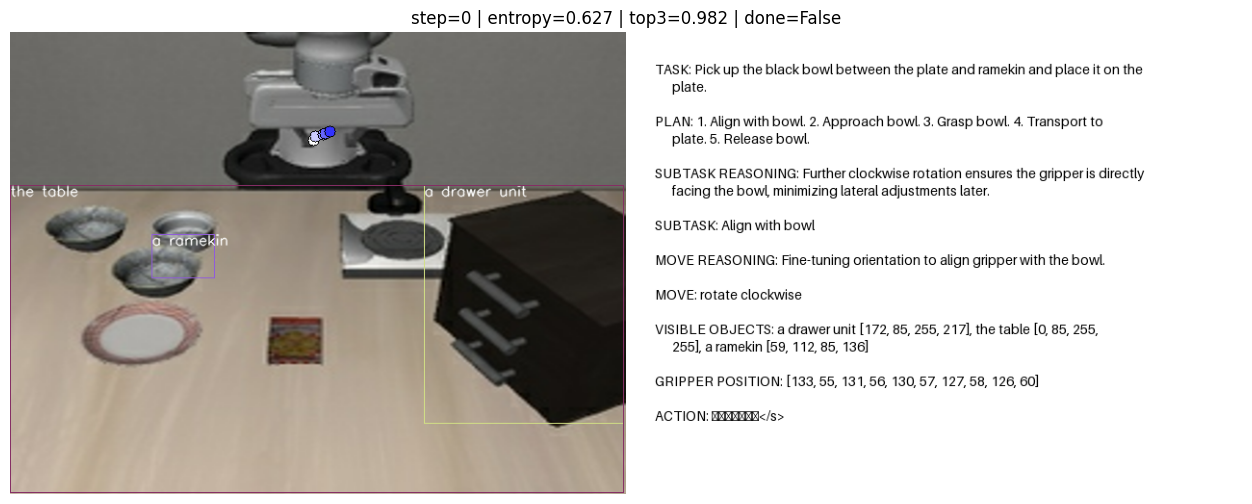

ACTION: [0.013000000268220901, -0.00039999998989515007, 0.007600000128149986, 0.006899999920278788, -0.010200000368058681, 0.2029999941587448, 0.9961000084877014]
DONE: False
REWARD: 0.0
INFO: {}

Parsed keys: [None, ' TASK:', ' PLAN:', ' SUBTASK REASONING:', ' SUBTASK:', ' MOVE REASONING:', ' MOVE:', ' GRIPPER POSITION:', ' VISIBLE OBJECTS:', ' ACTION:']
Parsed gripper: [(133, 55), (131, 56), (130, 57), (127, 58), (126, 60)]
Parsed bboxes: {'a drawer unit': [172, 85, 255, 217], 'the table': [0, 85, 255, 255], 'a ramekin': [59, 112, 85, 136]}


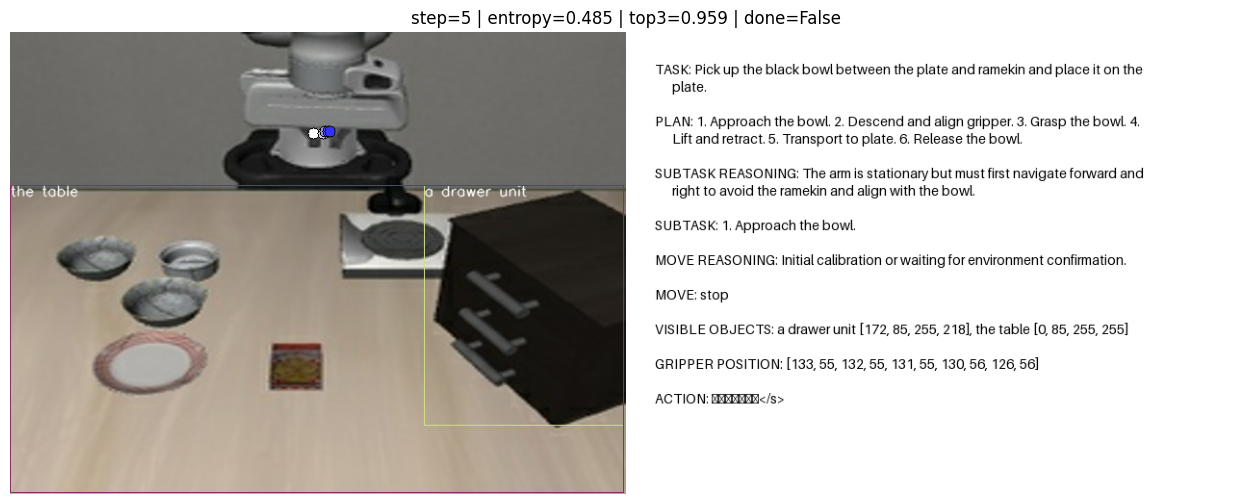

ACTION: [0.016300000250339508, 0.014100000262260437, 0.007600000128149986, 0.04259999841451645, 0.0026000000070780516, 0.2029999941587448, 0.9961000084877014]
DONE: False
REWARD: 0.0
INFO: {}

Parsed keys: [None, ' TASK:', ' PLAN:', ' SUBTASK REASONING:', ' SUBTASK:', ' MOVE REASONING:', ' MOVE:', ' GRIPPER POSITION:', ' VISIBLE OBJECTS:', ' ACTION:']
Parsed gripper: [(133, 55), (132, 55), (131, 55), (130, 56), (126, 56)]
Parsed bboxes: {'a drawer unit': [172, 85, 255, 218], 'the table': [0, 85, 255, 255]}


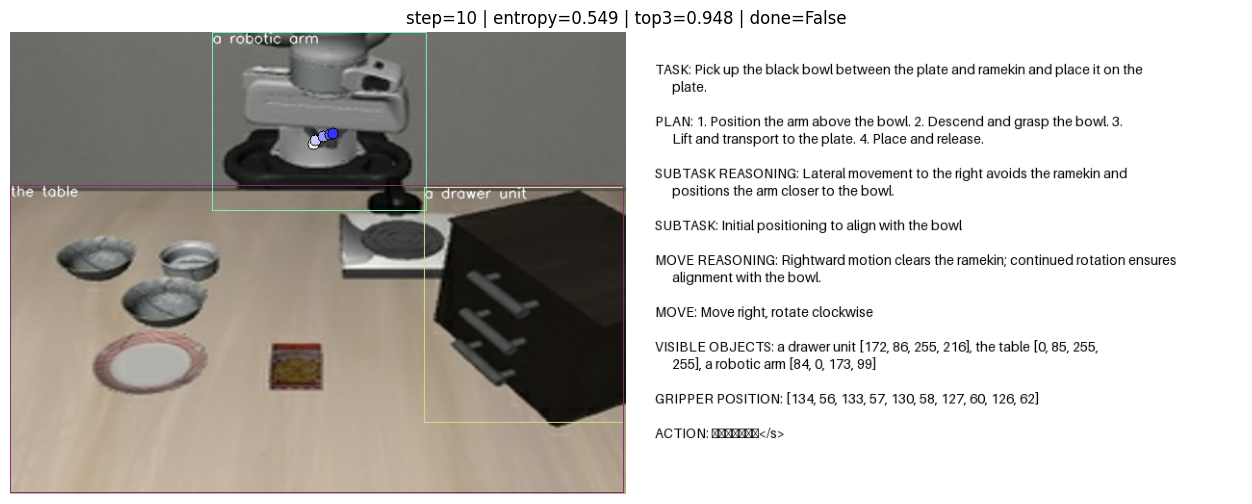

ACTION: [0.005200000014156103, 0.00930000003427267, -0.012199999764561653, 0.006899999920278788, 0.0026000000070780516, -0.0017000000225380063, 0.9961000084877014]
DONE: False
REWARD: 0.0
INFO: {}

Parsed keys: [None, ' TASK:', ' PLAN:', ' SUBTASK REASONING:', ' SUBTASK:', ' MOVE REASONING:', ' MOVE:', ' GRIPPER POSITION:', ' VISIBLE OBJECTS:', ' ACTION:']
Parsed gripper: [(134, 56), (133, 57), (130, 58), (127, 60), (126, 62)]
Parsed bboxes: {'a drawer unit': [172, 86, 255, 216], 'the table': [0, 85, 255, 255], 'a robotic arm': [84, 0, 173, 99]}


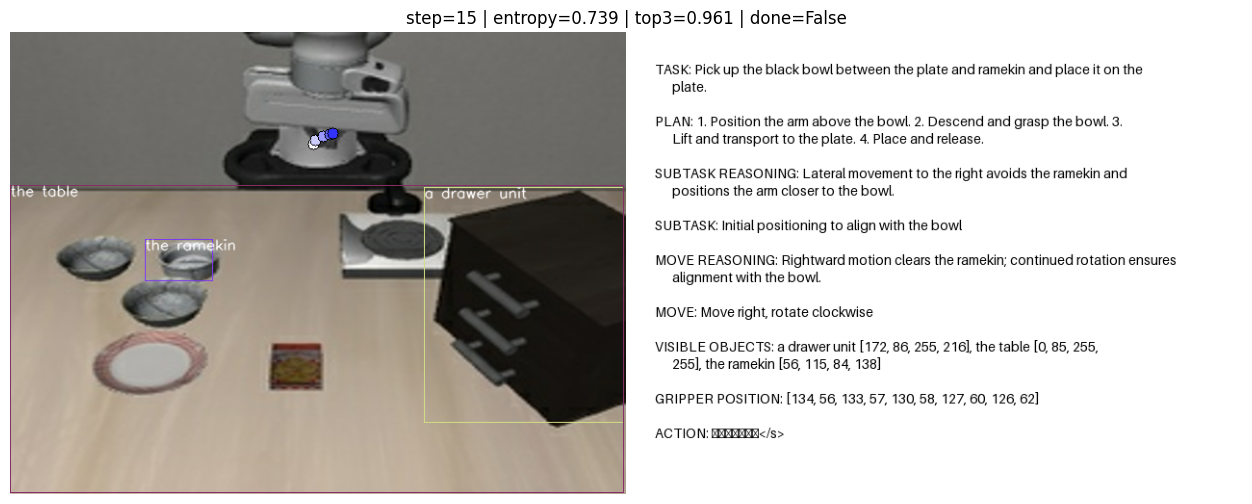

ACTION: [0.016100000590085983, 0.018400000408291817, 0.007600000128149986, 0.010700000450015068, -0.002099999925121665, 0.2029999941587448, 0.9961000084877014]
DONE: False
REWARD: 0.0
INFO: {}

Parsed keys: [None, ' TASK:', ' PLAN:', ' SUBTASK REASONING:', ' SUBTASK:', ' MOVE REASONING:', ' MOVE:', ' GRIPPER POSITION:', ' VISIBLE OBJECTS:', ' ACTION:']
Parsed gripper: [(134, 56), (133, 57), (130, 58), (127, 60), (126, 62)]
Parsed bboxes: {'a drawer unit': [172, 86, 255, 216], 'the table': [0, 85, 255, 255], 'the ramekin': [56, 115, 84, 138]}


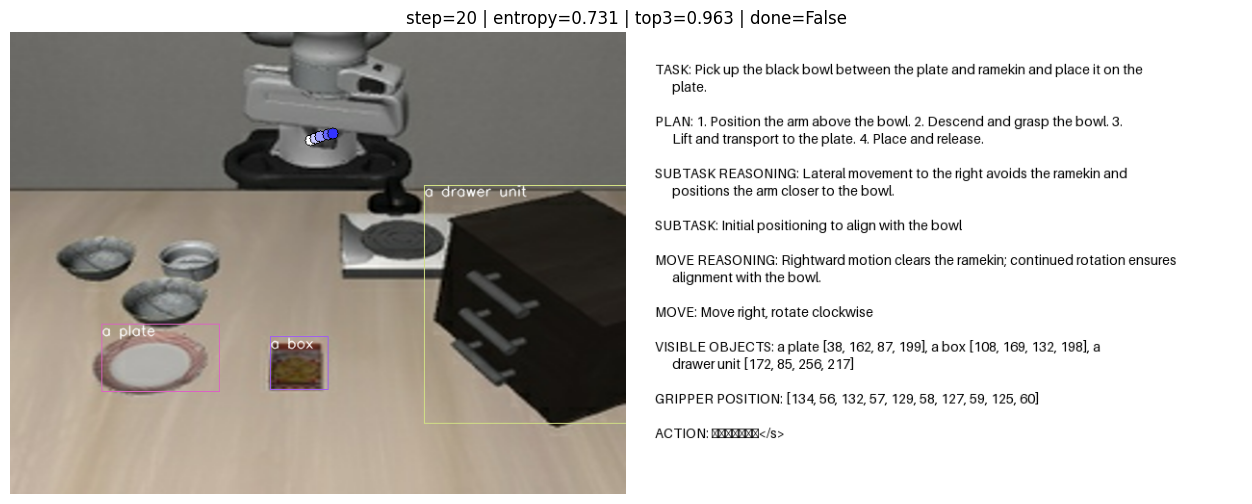

ACTION: [0.015699999406933784, 0.0035000001080334187, 0.007600000128149986, 0.003100000089034438, -0.008100000210106373, -0.0017000000225380063, 0.9961000084877014]
DONE: False
REWARD: 0.0
INFO: {}

Parsed keys: [None, ' TASK:', ' PLAN:', ' SUBTASK REASONING:', ' SUBTASK:', ' MOVE REASONING:', ' MOVE:', ' GRIPPER POSITION:', ' VISIBLE OBJECTS:', ' ACTION:']
Parsed gripper: [(134, 56), (132, 57), (129, 58), (127, 59), (125, 60)]
Parsed bboxes: {'a plate': [38, 162, 87, 199], 'a box': [108, 169, 132, 198], 'a drawer unit': [172, 85, 256, 217]}


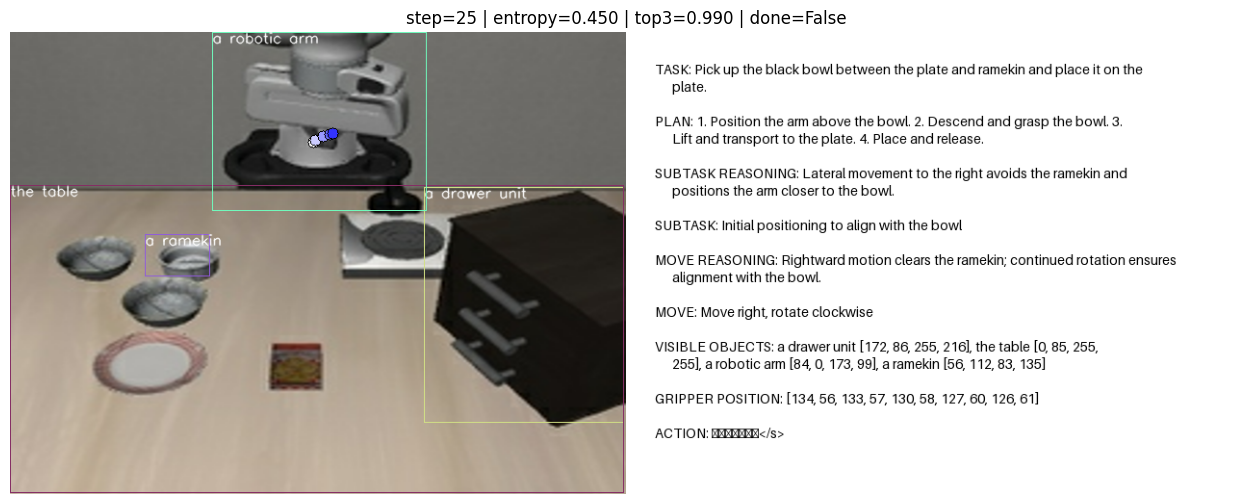

ACTION: [0.014800000004470348, 0.0066999997943639755, 0.007600000128149986, 0.007499999832361937, -0.008799999952316284, 0.2029999941587448, 0.9961000084877014]
DONE: False
REWARD: 0.0
INFO: {}

Parsed keys: [None, ' TASK:', ' PLAN:', ' SUBTASK REASONING:', ' SUBTASK:', ' MOVE REASONING:', ' MOVE:', ' GRIPPER POSITION:', ' VISIBLE OBJECTS:', ' ACTION:']
Parsed gripper: [(134, 56), (133, 57), (130, 58), (127, 60), (126, 61)]
Parsed bboxes: {'a drawer unit': [172, 86, 255, 216], 'the table': [0, 85, 255, 255], 'a robotic arm': [84, 0, 173, 99], 'a ramekin': [56, 112, 83, 135]}


In [33]:
show_debug_step("./debug_ecot_task0_trial0", 0)
show_debug_step("./debug_ecot_task0_trial0", 5)
show_debug_step("./debug_ecot_task0_trial0", 10)
show_debug_step("./debug_ecot_task0_trial0", 15)
show_debug_step("./debug_ecot_task0_trial0", 20)
show_debug_step("./debug_ecot_task0_trial0", 25)


In [12]:
for key in vla.config.norm_stats.keys():
    print(f"\n\n=== Unnorm key: {key} ===")
    records = debug_one_task(
        task_suite=task_suite,
        task_id=0,
        trial_id=0,
        max_steps=30,
        out_dir=f"./debug_ecot_{key}_task0_trial0_r32",
        use_frozen_prompt_controller=False,
        unnorm_key=key,
    )



=== Unnorm key: austin_buds_dataset_converted_externally_to_rlds ===
TASK: pick up the black bowl between the plate and the ramekin and place it on the plate



--- step 0 ---
entropy: 0.8705414533615112
top3_mass: 0.9326738119125366
action: [ 0.4549  0.157  -0.1852  0.      0.      0.      0.9961]
decoded preview: <s> A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: What action should the robot take to pick up the black bowl between the plate and the ramekin and place it on the plate? ASSISTANT:  TASK: Pick up the black bowl between the plate and ramekin and place it on the plate. PLAN: 1. Positio

--- step 1 ---
entropy: 0.9193807244300842
top3_mass: 0.9174315333366394
action: [ 0.4157  0.0927 -0.332   0.      0.      0.      0.9961]
decoded preview: <s> A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: What action should the robot take to pick up the black bowl between the plate and the ramekin and place it on the plate?

In [ ]:
for key in vla.config.norm_stats.keys():

    show_debug_step(f"./debug_ecot_{key}_task0_trial0_r32", 15)


In [ ]:
task = task_suite.get_task(0)
initial_states = task_suite.get_task_init_states(0)
env, task_description = get_libero_env(task, "openvla", resolution=256)

env.reset()
obs = env.set_init_state(initial_states[0])
image = to_image(obs)

prompt = (
    "A chat between a curious user and an artificial intelligence assistant. "
    "The assistant gives helpful, detailed, and polite answers to the user's questions. "
    f"USER: What action should the robot take to {task_description.lower()}? ASSISTANT: TASK:"
)

inputs = processor(prompt, image, return_tensors="pt").to(device, dtype=torch.bfloat16)
input_ids = inputs["input_ids"]
input_ids = torch.cat(
    [input_ids, torch.tensor([[29871]], device=input_ids.device, dtype=input_ids.dtype)],
    dim=1
)
# with torch.inference_mode():
#     action, generated_ids = vla.predict_action(
#         **inputs,
#         unnorm_key="bridge_reasoning",
#         max_new_tokens=1024,
#     )

# generated_text = processor.batch_decode(generated_ids)[0]

# print("TASK:", task_description)
# print("ACTION:", action)
# print("DECODED:", generated_text[:1200])
# image

for key in vla.config.norm_stats.keys():
    try:
        with torch.inference_mode():
            action = vla.predict_action(
                **inputs,
                unnorm_key=key,
                # max_new_tokens=1024,
            )
        print(key, action)
    except Exception as e:
        print("FAIL", key, e)

austin_buds_dataset_converted_externally_to_rlds [0.99607843 0.85643139 0.99633053 0.         0.         0.
 0.99607843]
austin_sailor_dataset_converted_externally_to_rlds [0.99607843 0.94193278 0.99686275 0.         0.         0.17823949
 0.99607843]
austin_sirius_dataset_converted_externally_to_rlds [0.95355619 0.6946593  0.80986544 0.         0.         0.19619757
 0.99607843]
bc_z [0.07595829 0.05777938 0.05234146 0.11694849 0.11653276 0.16652366
 0.99607843]
berkeley_autolab_ur5 [0.01992157 0.01992157 0.01992157 0.03169561 0.06640523 0.03642428
 0.99607843]
berkeley_cable_routing [0.42460686 0.49817319 0.63752673 0.         0.         0.98057767
 0.99607843]
berkeley_fanuc_manipulation [0.00996078 0.00996078 0.00996078 0.0347697  0.         0.0347697
 0.99607843]
bridge_reasoning [0.02819784 0.04069337 0.04003167 0.08160118 0.07759357 0.20301985
 0.99607843]
cmu_stretch [0.01445144 0.         0.01502027 0.         0.         0.
 0.99607843]
dlr_edan_shared_control_converted_extern

In [20]:
candidate_keys = [
    "taco_play",
    "viola",
    "austin_buds_dataset_converted_externally_to_rlds",
    "fmb_dataset",
    "fractal20220817_data",
    "iamlab_cmu_pickup_insert_converted_externally_to_rlds",
    "ucsd_kitchen_dataset_converted_externally_to_rlds",
]

task_suite_name = "libero_spatial"
benchmark_dict = benchmark.get_benchmark_dict()
all_results = []
task_suite_class = benchmark_dict[task_suite_name]
task_suite = task_suite_class()  # Instantiate the class


for key in candidate_keys:
    task_id = 0
    task = task_suite.get_task(task_id)
    initial_states = task_suite.get_task_init_states(task_id)
    env, task_description = get_libero_env(task, "openvla", resolution=256)
    print(task_description)
    print(f"\n\n=== Running rollouts for unnorm key: {key} ===")
    

# for task_id, task_description in enumerate(task_descriptions):
    for trial_id in tqdm(range(1), desc=f"Task {task_id} Trials for Unnorm key {key}", leave=False):
        out = run_one_rollout_ecot(
            env=env,
            task_description=task_description,
            task_id=task_id,
            trial_id=trial_id,
            max_steps=100,
            save_dir=f"./experiments/logs/{key}_one_rollout",
            image_from_obs_fn=to_image,
            use_frozen_prompt_controller=False,
            unnorm_key=key,
        )
        all_results.append(out)
        print(task_id, trial_id, out["success"], out["traj_len"])

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


pick up the black bowl between the plate and the ramekin and place it on the plate


0 0 0 100


pick up the black bowl between the plate and the ramekin and place it on the plate


0 0 0 100


...

0 0 0 100


pick up the black bowl between the plate and the ramekin and place it on the plate


0 0 0 100


pick up the black bowl between the plate and the ramekin and place it on the plate


KeyboardInterrupt: 

In [22]:
candidate_keys = [
    "berkeley_cable_routing",
    "roboturk",
    "furniture_bench_dataset_converted_externally_to_rlds",
    "utaustin_mutex",
    "iamlab_cmu_pickup_insert_converted_externally_to_rlds",
    
    
]

task_suite_name = "libero_spatial"
benchmark_dict = benchmark.get_benchmark_dict()
all_results = []
task_suite_class = benchmark_dict[task_suite_name]
task_suite = task_suite_class()  # Instantiate the class


for key in candidate_keys:
    task_id = 0
    task = task_suite.get_task(task_id)
    initial_states = task_suite.get_task_init_states(task_id)
    env, task_description = get_libero_env(task, "openvla", resolution=256)
    print(task_description)
    print(f"\n\n=== Running rollouts for unnorm key: {key} ===")
    

# for task_id, task_description in enumerate(task_descriptions):
    for trial_id in tqdm(range(1), desc=f"Task {task_id} Trials for Unnorm key {key}", leave=False):
        out = run_one_rollout_ecot(
            env=env,
            task_description=task_description,
            task_id=task_id,
            trial_id=trial_id,
            max_steps=120,
            save_dir=f"./experiments/logs/{key}_one_rollout",
            image_from_obs_fn=to_image,
            use_frozen_prompt_controller=False,
            unnorm_key=key,
        )
        all_results.append(out)
        print(task_id, trial_id, out["success"], out["traj_len"])

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
pick up the black bowl between the plate and the ramekin and place it on the plate


=== Running rollouts for unnorm key: berkeley_cable_routing ===


Rollout Steps: 100%|██████████| 120/120 [10:32<00:00,  5.27s/it]    | 0/1 [00:00<?, ?it/s]


0 0 0 120
pick up the black bowl between the plate and the ramekin and place it on the plate


=== Running rollouts for unnorm key: roboturk ===


Rollout Steps: 100%|██████████| 120/120 [09:51<00:00,  4.93s/it]00<?, ?it/s]


0 0 0 120
pick up the black bowl between the plate and the ramekin and place it on the plate


=== Running rollouts for unnorm key: furniture_bench_dataset_converted_externally_to_rlds ===


...

0 0 0 120
pick up the black bowl between the plate and the ramekin and place it on the plate


=== Running rollouts for unnorm key: utaustin_mutex ===


Rollout Steps: 100%|██████████| 120/120 [09:38<00:00,  4.82s/it]1 [00:00<?, ?it/s]


0 0 0 120
pick up the black bowl between the plate and the ramekin and place it on the plate


=== Running rollouts for unnorm key: iamlab_cmu_pickup_insert_converted_externally_to_rlds ===


Rollout Steps:   0%|          | 0/120 [00:02<?, ?it/s]converted_externally_to_rlds:   0%|          | 0/1 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [11]:
ds = {
  "libero_spatial_no_noops": {
    "action": {
      "mean": [
        0.15312516689300537,
        0.13707207143306732,
        -0.1552680879831314,
        -0.005176449194550514,
        -0.01120870839804411,
        -0.020194243639707565,
        0.4578818082809448
      ],
      "std": [
        0.412727415561676,
        0.3472459018230438,
        0.5086913704872131,
        0.037266023457050323,
        0.07244453579187393,
        0.057623401284217834,
        0.49828314781188965
      ],
      "max": [
        0.9375,
        0.9375,
        0.9375,
        0.1971428543329239,
        0.33642858266830444,
        0.375,
        1.0
      ],
      "min": [
        -0.9375,
        -0.9375,
        -0.9375,
        -0.1875,
        -0.3675000071525574,
        -0.36000001430511475,
        0.0
      ],
      "q01": [
        -0.7454732114076613,
        -0.6616071462631226,
        -0.9375,
        -0.1071428582072258,
        -0.20678570866584778,
        -0.1842857152223587,
        0.0
      ],
      "q99": [
        0.9375,
        0.8758928775787354,
        0.9321428537368774,
        0.1039285734295845,
        0.17678570747375488,
        0.14571428298950195,
        1.0
      ],
      "mask": [
        True,
        True,
        True,
        True,
        True,
        True,
        False
      ]
    },
    "proprio": {
      "mean": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0
      ],
      "std": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0
      ],
      "max": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0
      ],
      "min": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0
      ],
      "q01": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0
      ],
      "q99": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0
      ]
    },
    "num_transitions": 52970,
    "num_trajectories": 432
  }
}

In [12]:
# from huggingface_hub import hf_hub_download

# stats_file = hf_hub_download(repo_id=path, filename="dataset_statistics.json")
# with open(stats_file, "r") as f:
#     ds = json.load(f)

# # Option 1: keep the original key name from dataset_statistics.json
# vla.norm_stats = dict(vla.norm_stats)
vla.norm_stats["libero_spatial_no_noops"] = ds["libero_spatial_no_noops"]
vla.config.norm_stats = vla.norm_stats

key = "libero_spatial_no_noops"

task_suite_name = "libero_spatial"
benchmark_dict = benchmark.get_benchmark_dict()
all_results = []
task_suite_class = benchmark_dict[task_suite_name]
task_suite = task_suite_class()  # Instantiate the class


task_id = 0
task = task_suite.get_task(task_id)
initial_states = task_suite.get_task_init_states(task_id)
env, task_description = get_libero_env(task, "openvla", resolution=256)
print(task_description)
print(f"\n\n=== Running rollouts for unnorm key: {key} ===")


# for task_id, task_description in enumerate(task_descriptions):
for trial_id in tqdm(range(1), desc=f"Task {task_id} Trials for Unnorm key {key}", leave=False):
    out = run_one_rollout_ecot(
        env=env,
        task_description=task_description,
        task_id=task_id,
        trial_id=trial_id,
        max_steps=120,
        save_dir=f"./experiments/logs/{key}_one_rollout",
        image_from_obs_fn=to_image,
        use_frozen_prompt_controller=False,
        unnorm_key=key,
    )
    all_results.append(out)
    print(task_id, trial_id, out["success"], out["traj_len"])

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
pick up the black bowl between the plate and the ramekin and place it on the plate


=== Running rollouts for unnorm key: libero_spatial_no_noops ===


Task 0 Trials for Unnorm key libero_spatial_no_noops:   0%|          | 0/1 [00:00<?, ?it/s]2026-04-03 14:21:28.016912: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 14:21:28.017265: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 14:21:28.017961: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more a

0 0 0 120


In [ ]:
task_suite_name = "libero_spatial"
benchmark_dict = benchmark.get_benchmark_dict()
all_results = []

task_suite_class = benchmark_dict[task_suite_name]
task_suite = task_suite_class()  # Instantiate the class

for task_id in range(task_suite.n_tasks):
    task_id = 0
    task = task_suite.get_task(task_id)
    initial_states = task_suite.get_task_init_states(task_id)
    env, task_description = get_libero_env(task, "openvla", resolution=256)
    print(task_description)

# for task_id, task_description in enumerate(task_descriptions):
    for trial_id in tqdm(range(1), desc=f"Task {task_id} Trials for Unnorm key {key}", leave=False):
        out = run_one_rollout_ecot(
            env=env,
            task_description=task_description,
            task_id=task_id,
            trial_id=trial_id,
            max_steps=90,
            save_dir=f"./experiments/logs/{key}_one_rollout",
            image_from_obs_fn=to_image,
            use_frozen_prompt_controller=False
        )
        all_results.append(out)
        print(task_id, trial_id, out["success"], out["traj_len"])

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


pick up the black bowl between the plate and the ramekin and place it on the plate


Task 0 Trials:   0%|          | 0/10 [00:00<?, ?it/s]2026-04-03 01:40:27.357111: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 01:40:27.357310: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 01:40:27.357705: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/bl

0 0 0 300


Task 0 Trials:  20%|██        | 2/10 [40:08<2:40:55, 1206.93s/it]

...

0 3 0 300


Task 0 Trials:  50%|█████     | 5/10 [1:38:18<1:38:40, 1184.03s/it]

0 4 0 300


Task 0 Trials:  60%|██████    | 6/10 [1:56:07<1:16:19, 1144.82s/it]

0 5 0 300
